### Configure here

In [22]:
# Camelyon16, NSCLC, TCGA_CRC, STANFORD_793
dataset = "STANFORD_793"
output_folder = "Paired_wilcoxon_signed_rank_test"
csv_path = f"/data_64T_3/Raja/MUFASA/1.WSI_Classification/Statistical_Analysis/data/{dataset}_Results.csv"

### Normality test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
baselines     = ["CLAM", "Histolab", "Trident"]
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)
for c in ["acc", "bacc", "macro_auc", "macro_f1"]:
    df_raw[c] = pd.to_numeric(df_raw[c].astype(str).str.strip(), errors="coerce")

print(f"Loaded: {df_raw.shape[0]} rows")
print(f"Methods found: {df_raw['method'].unique().tolist()}")
print(f"Models found:  {df_raw['model'].nunique()} unique models\n")

# ─────────────────────────────────────────────
# BUILD DELTA DATAFRAME
# one row per (model, fold, baseline, metric)
# ─────────────────────────────────────────────
mufasa = df_raw[df_raw['method'] == 'MUFASA'].copy()
rows   = []

for b in baselines:
    base   = df_raw[df_raw['method'] == b].copy()
    merged = mufasa.merge(base,
                          on=['Dataset', 'task', 'model', 'run_id'],
                          suffixes=('_mufasa', '_base'))
    for metric in metrics:
        merged[f'd_{metric}'] = (merged[f'{metric}_mufasa']
                               - merged[f'{metric}_base'])

    for _, row in merged.iterrows():
        for metric in metrics:
            rows.append({
                'model':    row['model'],
                'run_id':   row['run_id'],
                'baseline': b,
                'metric':   metric,
                'delta':    row[f'd_{metric}']
            })

delta_long = pd.DataFrame(rows)
print(f"Delta dataframe: {delta_long.shape[0]} rows")
print(f"  {delta_long['model'].nunique()} models × "
      f"{delta_long['run_id'].nunique()} folds × "
      f"{len(baselines)} baselines × {len(metrics)} metrics\n")

# ─────────────────────────────────────────────
# SHAPIRO-WILK NORMALITY TEST
# ─────────────────────────────────────────────
print("=" * 65)
print("SHAPIRO-WILK NORMALITY TEST ON DELTA DISTRIBUTIONS")
print("H0: deltas are normally distributed")
print("p > 0.05 → normal   |   p <= 0.05 → non-normal")
print("=" * 65)

results = []

for metric, label in zip(metrics, metric_labels):
    print(f"\n{label}:")
    print("-" * 55)
    for baseline in baselines:
        vals = delta_long[
            (delta_long['metric']   == metric) &
            (delta_long['baseline'] == baseline)
        ]['delta'].dropna().values

        if len(vals) >= 3:
            stat, p = shapiro(vals)
            normal  = p > 0.05
            verdict = "normal ✓" if normal else "NON-NORMAL ✗"
            print(f"  MUFASA vs {baseline:10s} | "
                  f"n={len(vals):3d} | "
                  f"W={stat:.4f} | "
                  f"p={p:.4f} | {verdict}")
        else:
            stat, p, normal, verdict = np.nan, np.nan, False, "too few samples"
            print(f"  MUFASA vs {baseline:10s} | n={len(vals)} — {verdict}")

        results.append({
            'metric':   metric,
            'label':    label,
            'baseline': baseline,
            'n':        len(vals),
            'W_stat':   round(stat, 4) if not np.isnan(stat) else np.nan,
            'p_value':  round(p,    4) if not np.isnan(p)    else np.nan,
            'normal':   normal,
            'verdict':  verdict
        })

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
results_df = pd.DataFrame(results)

print("\n" + "=" * 65)
print("SUMMARY — recommended test based on normality")
print("=" * 65)

for metric, label in zip(metrics, metric_labels):
    subset      = results_df[results_df['metric'] == metric]
    all_normal  = subset['normal'].all()
    any_normal  = subset['normal'].any()
    recommended = "Paired t-test / N&B" if all_normal else "Wilcoxon / Bootstrap"
    print(f"  {label:12s} → all normal: {str(all_normal):5s} "
          f"→ recommended: {recommended}")

# ─────────────────────────────────────────────
# OVERALL RECOMMENDATION
# ─────────────────────────────────────────────
all_normal_overall = results_df['normal'].all()

print("\n" + "=" * 65)
print("OVERALL RECOMMENDATION")
print("=" * 65)
if all_normal_overall:
    print("""  All deltas are normally distributed.
  → Use Nadeau & Bengio corrected t-test (accounts for CV overlap)
  → Or Linear Mixed Effects Model (accounts for model heterogeneity)""")
else:
    print("""  Some deltas are NON-NORMAL.
  → Use Bootstrap CI (no normality assumption)
  → Or Wilcoxon signed-rank test
  → Mixed Effects Model is still valid (robust to mild non-normality)""")

### Confidence Interval Calculation (Bootstrap based)

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
from matplotlib.ticker import MaxNLocator

# Directly set matplotlib parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    # Optional: Add some aesthetically pleasing settings
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'grid.color': 'lightgray',
    'grid.linestyle': '--'
})

def preprocess_data(csv_path):
    """
    Preprocess the CSV data
    """
    # Read the CSV
    raw = pd.read_csv(csv_path)

    # Clean numeric columns
    for c in ["acc","bacc","macro_auc","macro_f1"]:
        raw[c] = raw[c].astype(str).str.strip()
        raw[c] = raw[c].str.replace(r"\.\.+", ".", regex=True)
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

    # Identify bad rows
    bad_mask = raw[["acc","bacc","macro_auc","macro_f1"]].isna().any(axis=1)
    bad_rows = raw[bad_mask].copy()

    # Define baselines and metrics
    baselines = ["CLAM","Histolab","Trident"]
    metrics = ["macro_auc"]
    mufasa = raw[raw.method=="MUFASA"].copy()

    # Calculate deltas
    deltas = []
    for b in baselines:
        base = raw[raw.method==b].copy()
        merged = mufasa.merge(base, on=["Dataset","task","model","run_id"], suffixes=("_mufasa", "_base"))
        for met in metrics:
            merged[f"d_{met}"] = merged[f"{met}_mufasa"] - merged[f"{met}_base"]
        out = merged[["Dataset","task","model","run_id"]+[f"d_{m}" for m in metrics]].copy()
        out.insert(3,"baseline",b)
        deltas.append(out)
    delta_df = pd.concat(deltas, ignore_index=True).sort_values(["Dataset","model","baseline","run_id"])

    return delta_df, bad_rows

def bootstrap_ci(x, n_boot=20000, alpha=0.05, seed=42):
    """
    Calculate bootstrap confidence intervals
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    boots = rng.choice(x, size=(n_boot, n), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return (x.mean(), lo, hi)

def summarize_results(delta_df, metrics=['macro_auc']):
    """
    Summarize results with bootstrap confidence intervals
    """
    summary_rows = []
    for (ds, task, model, baseline), g in delta_df.groupby(["Dataset","task","model","baseline"]):
        for met in metrics:
            mean_, lo, hi = bootstrap_ci(g[f"d_{met}"].values)
            summary_rows.append({
                "Dataset": ds, 
                "task": task, 
                "model": model, 
                "baseline": baseline,
                "metric": met, 
                "delta_mean": mean_, 
                "ci_low": lo, 
                "ci_high": hi, 
                "n": len(g)
            })
            
    # Create the DataFrame
    df = pd.DataFrame(summary_rows)
    
    # --- ADD TRUNCATION/ROUNDING HERE ---
    cols_to_round = ["delta_mean", "ci_low", "ci_high"]
    df[cols_to_round] = df[cols_to_round].round(2)
    # ------------------------------------

    return df.sort_values(["Dataset","model","metric","baseline"])

def create_compact_forest_plot(summary_df, metric='macro_auc'):
    """
    Create a compact, column-wise forest plot for macro AUC
    """
    # Filter for specified metric
    plot_data = summary_df[summary_df.metric == metric].copy()
    
    # Prepare figure
    fig, ax = plt.subplots(figsize=(6, 3))
    
    # Color palettes
    baseline_colors = {
        'CLAM': '#1F77B4',      # Blue
        'Histolab': '#FF7F0E',  # Orange
        'Trident': '#2CA02C'    # Green
    }
    
    # Group models
    unique_models = plot_data['model'].unique()
    
    # Plot setup
    bar_width = 0.25
    index = np.arange(len(unique_models))
    
    # Plot for each baseline
    for i, baseline in enumerate(plot_data['baseline'].unique()):
        # Collect delta means for this baseline
        delta_means = []
        ci_lows = []
        ci_highs = []
        
        for model in unique_models:
            # Find the specific row
            row = plot_data[(plot_data['baseline'] == baseline) & 
                            (plot_data['model'] == model)]
            
            if not row.empty:
                delta_means.append(row['delta_mean'].values[0])
                ci_lows.append(row['delta_mean'].values[0] - row['ci_low'].values[0])
                ci_highs.append(row['ci_high'].values[0] - row['delta_mean'].values[0])
            else:
                delta_means.append(0)
                ci_lows.append(0)
                ci_highs.append(0)
        
        # Plot bars with error bars
        ax.bar(
            index + i*bar_width, 
            delta_means, 
            bar_width, 
            yerr=[ci_lows, ci_highs],
            label=baseline,
            color=baseline_colors[baseline],
            capsize=3,
            alpha=0.7,
            error_kw={
                'elinewidth': 0.75,      # Thickness of the vertical line
                'capthick': 0.75,        # Thickness of the horizontal caps
                'ecolor': 'black'     # Optional: Color of the error bars
            }
        )
    
    # Customize plot
    # ax.set_xlabel('Models', fontsize=12)
    # ax.set_ylabel('Mean Difference in Macro AUC', fontsize=12)
    ax.set_ylabel('ΔMacro-AUC', fontsize=9)
    # ax.set_title('(a) Performance Difference: ΔMacro-AUC (MUFASA-Baselines)', fontsize=14)
    
    # X-axis ticks
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(unique_models, rotation=45, ha='right', fontsize=9)
    
    # Horizontal line at zero
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(title='Baseline', loc='best', title_fontsize=9, fontsize=8.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 

    ax.yaxis.grid(True, linestyle=':', which='major', color='grey', alpha=0.7, linewidth=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    # # Additional options 
    plt.savefig(f'{output_folder}/{dataset}_CI.png', 
                dpi=400,  # Resolution
                bbox_inches='tight',  # Removes extra white space
                pad_inches=0.1)  # Padding around the plot
    plt.show()

def assess_significance(summary_df, metric='macro_auc'):
    """
    Assess statistical significance of MUFASA improvements
    """
    significant_improvements = summary_df[
        (summary_df['metric'] == metric) & 
        ((summary_df['ci_low'] > 0) | (summary_df['ci_high'] < 0))
    ]
    return significant_improvements

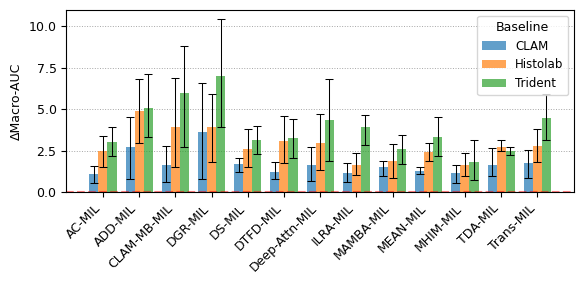


Statistically Significant Improvements:
       Dataset          model  baseline  delta_mean  ci_low  ci_high
0   Camelyon16         AC-MIL      CLAM        1.07    0.57     1.57
1   Camelyon16         AC-MIL  Histolab        2.45    1.52     3.39
2   Camelyon16         AC-MIL   Trident        3.00    2.15     3.95
3   Camelyon16        ADD-MIL      CLAM        2.72    0.77     4.52
4   Camelyon16        ADD-MIL  Histolab        4.89    2.98     6.79
5   Camelyon16        ADD-MIL   Trident        5.09    3.33     7.13
6   Camelyon16    CLAM-MB-MIL      CLAM        1.62    0.62     2.80
7   Camelyon16    CLAM-MB-MIL  Histolab        3.94    1.54     6.88
8   Camelyon16    CLAM-MB-MIL   Trident        5.96    2.70     8.77
9   Camelyon16        DGR-MIL      CLAM        3.62    0.81     6.57
10  Camelyon16        DGR-MIL  Histolab        3.91    1.84     5.88
11  Camelyon16        DGR-MIL   Trident        6.99    3.94    10.44
12  Camelyon16         DS-MIL      CLAM        1.68    1.19   

In [24]:
def main():
    # Load and preprocess data 
    delta_df, bad_rows = preprocess_data(csv_path)
    os.makedirs(os.path.dirname(f"{output_folder}/"), exist_ok=True)
    output_path_sig = f"{output_folder}/{dataset}_Significant_Improvements_CI.csv"
    
    # Summarize results
    summary_df = summarize_results(delta_df)
    
    # Create forest plot
    create_compact_forest_plot(summary_df)
    
    # Check significant improvements
    sig_improvements = assess_significance(summary_df)
    print("\nStatistically Significant Improvements:")
    print(sig_improvements[['Dataset', 'model', 'baseline', 'delta_mean', 'ci_low', 'ci_high']])

    # Save everything
    summary_df.to_csv(f"{output_folder}/{dataset}_Significant_Full_Summary.csv", index=False, encoding='utf-8-sig')

    # Save only significant
    sig_improvements.to_csv(f"{output_folder}/{dataset}_Significant_Only.csv", index=False, encoding='utf-8-sig')
    
    # sig_improvements.to_csv(output_path_sig, index=False, encoding='utf-8-sig')
    print(f"\n✅ Significant improvements saved to: {output_path_sig}")

if __name__ == "__main__":
    main()

### Mean and standard deviation for tables in the manuscript and 
### Piared Wilcoxon signed-rank statistical test across model

Calculated Mean and Std for each (Model, Method) combination:
            Model Pre-processor acc_mean_std bacc_mean_std macro_auc_mean_std macro_f1_mean_std
0          AC-MIL          CLAM   79.87±3.63    56.16±3.28         73.30±7.24        55.85±5.61
1          AC-MIL      Histolab   79.88±4.56    58.92±4.98         74.61±6.06        60.06±6.43
2          AC-MIL        MUFASA   82.52±2.85    62.62±3.50         77.40±4.97        64.70±4.73
3          AC-MIL       Trident   80.20±4.52    57.62±5.67         71.84±4.38        60.34±6.66
4         ADD-MIL          CLAM   79.80±2.58    52.95±3.76         70.33±5.98        52.11±7.73
5         ADD-MIL      Histolab   78.82±4.23    51.85±2.88         70.42±6.88        52.01±7.42
6         ADD-MIL        MUFASA   81.14±1.23    53.13±3.48         74.81±8.84        53.02±8.00
7         ADD-MIL       Trident   79.58±2.70    52.22±3.66         71.51±7.04        50.58±7.31
8     CLAM-MB-MIL          CLAM   82.10±1.21    51.61±3.76         69.47±7

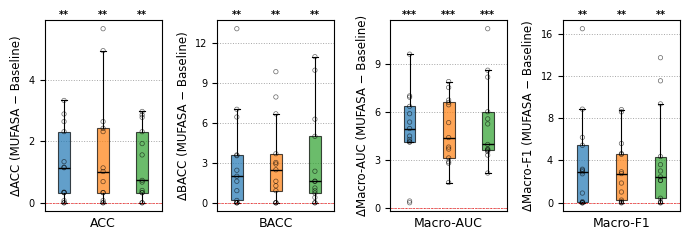

✅ Statistical report saved to: Paired_wilcoxon_signed_rank_test/TCGA_CRC_Wilcoxon_Stats_Report.txt

DISPLAYING SAVED REPORT FROM: Paired_wilcoxon_signed_rank_test/TCGA_CRC_Wilcoxon_Stats_Report.txt
WILCOXON SIGNED-RANK TEST RESULTS

ACC (mean_acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 1.14
    p-value:  3.3456e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Trident:
    Median Δ: 0.73
    p-value:  3.3456e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Histolab:
    Median Δ: 1.02
    p-value:  3.3456e-03
    Significance: ** (p < 0.01)

BACC (mean_bacc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Median Δ: 1.99
    p-value:  5.0620e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Trident:
    Median Δ: 1.62
    p-value:  3.3300e-03
    Significance: ** (p < 0.01)
  MUFASA vs. Histolab:
    Median Δ: 2.48
    p-value:  5.0620e-03
    Significance: ** (p < 0.01)

MACRO-AUC (mean_macro-auc

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings("ignore")

# Camelyon16, NSCLC, TCGA_CRC, STANFORD_793
dataset = "TCGA_CRC"
output_folder = "Paired_wilcoxon_signed_rank_test"
csv_path = f"/data_64T_3/Raja/MUFASA/1.WSI_Classification/Statistical_Analysis/data/{dataset}_Results.csv"

# Read the raw data
df_raw = pd.read_csv(csv_path) 

# Write the performance values in a csv file
output_path_csv = f"{output_folder}/{dataset}_Mean_Std_Results.csv"
stats_file_path = f"{output_folder}/{dataset}_Wilcoxon_Stats_Report.txt"

# Convert macro_f1 to numeric (it's stored as string in the CSV)
df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# Calculate population mean and population std (ddof=0)
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc': ['mean', lambda x: x.std(ddof=0)],
    'bacc': ['mean', lambda x: x.std(ddof=0)],
    'macro_auc': ['mean', lambda x: x.std(ddof=0)],
    'macro_f1': ['mean', lambda x: x.std(ddof=0)]
}).reset_index()

grouped.columns = ['Model', 'Pre-processor', 
                   'acc_mean', 'acc_std', 
                   'bacc_mean', 'bacc_std', 
                   'macro_auc_mean', 'macro_auc_std', 
                   'macro_f1_mean', 'macro_f1_std'] 

# Note: Ensure these strings match the names assigned above exactly
for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
    grouped[f'{m}_mean_std'] = grouped.apply(lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

# Rename columns for the plotting logic (keep these for your deltas/stats)
df = grouped.rename(columns={
    'acc_mean': 'mean_acc',
    'bacc_mean': 'mean_bacc',
    'macro_auc_mean': 'mean_macro-auc',
    'macro_f1_mean': 'mean_macro-f1'
})

print("Calculated Mean and Std for each (Model, Method) combination:")
# Use the newly created combined columns for the console output
print(df[['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std', 'macro_auc_mean_std', 'macro_f1_mean_std']].to_string())
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_path_csv), exist_ok=True)

# Save the specific columns you want
cols_to_save = ['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std', 'macro_auc_mean_std', 'macro_f1_mean_std']
df[cols_to_save].to_csv(output_path_csv, index=False, encoding='utf-8-sig')

print(f"✅ Summary results saved to: {output_path_csv}")
# ----------------------------------------------

metrics = ["mean_acc", "mean_bacc", "mean_macro-auc", "mean_macro-f1"]
metric_labels = ["ACC", "BACC", "Macro-AUC", "Macro-F1"]

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

all_results = {}

# Define your desired order explicitly here
order_keys = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

# Define colors mapped to the labels
baseline_colors = {
    'CLAM': '#1F77B4',      # Blue
    'Histolab': '#FF7F0E',  # Orange
    'Trident': '#2CA02C'    # Green
}
# Create color list in the matching order: [Blue, Orange, Green]
ordered_colors = [baseline_colors[l] for l in order_labels]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    
    # Pivot data
    pivot_metric = df.pivot(index="Model", columns="Pre-processor", values=metric)
    
    # Calculate deltas
    delta_metric = pd.DataFrame({
        "MUFASA_vs_CLAM": pivot_metric["MUFASA"] - pivot_metric["CLAM"],
        "MUFASA_vs_Trident": pivot_metric["MUFASA"] - pivot_metric["Trident"],
        "MUFASA_vs_Histolab": pivot_metric["MUFASA"] - pivot_metric["Histolab"],
    })
    
    # Statistical tests
    results = {}
    for col in delta_metric.columns:
        values = delta_metric[col].dropna()
        if len(values) > 1:
            stat, p = wilcoxon(values)
        else:
            stat, p = np.nan, np.nan
        results[col] = {"median_delta": np.median(values), "p_value": p}
    
    all_results[metric] = results
    
    # --- 1. PREPARE DATA IN NEW ORDER ---
    data_to_plot = [delta_metric[key] for key in order_keys]
    
    # --- 2. CREATE BOXPLOT WITH NEW LABELS ---
    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,  # Now ["CLAM", "Histolab", "Trident"]
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )
    
    # --- 3. COLOR BOXES IN NEW ORDER ---
    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Scatter individual points
    for i, vals in enumerate(data_to_plot, start=1): 
        ax.scatter(
            np.full(len(vals), i), vals, 
            alpha=0.6, s=10, facecolors='none', edgecolors='black', linewidth=0.5, zorder=3
        )
    
    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)

    ax.yaxis.grid(True, linestyle=':', alpha=0.7, color='grey', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # --- 4. ANNOTATE P-VALUES IN NEW ORDER ---
    y_max = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])
    
    # Iterate using order_keys to match the boxplot order
    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            ax.text(i, y_max + 0.05 * y_range, sig_marker, 
                   ha='center', va='bottom', fontsize=7, fontweight='bold', color='black')

plt.tight_layout() 
output_path = f"{output_folder}/{dataset}_Wilcoxon_Boxplot.png"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(f"{output_folder}/{dataset}_Wilcoxon.png", dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Print statistical results
# Ensure the output directory exists
os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)

caption = """
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across multiple evaluation metrics. 
Wilcoxon signed-rank tests were performed on paired differences (ΔMUFASA - Baseline) across all MIL models. 
Each box represents the distribution of performance differences, with individual model results shown as scatter points. 
The red dashed line indicates zero difference. Positive values indicate MUFASA outperforms the baseline. 
Statistical significance is indicated above each boxplot: 
*** p < 0.001, ** p < 0.01, * p < 0.05, ns: not significant (p ≥ 0.05).
"""

with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("="*80 + "\n")
    f.write("WILCOXON SIGNED-RANK TEST RESULTS\n")
    f.write("="*80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-" * 60 + "\n")
        for comparison, stats in all_results[metric].items():
            baseline = comparison.split("_vs_")[1]
            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    Median Δ: {stats['median_delta']:.2f}\n")
            
            p_str = f"{stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "N/A"
            f.write(f"    p-value:  {p_str}\n")
            
            if not np.isnan(stats['p_value']):
                if stats['p_value'] < 0.001: sig = "*** (p < 0.001)"
                elif stats['p_value'] < 0.01: sig = "** (p < 0.01)"
                elif stats['p_value'] < 0.05: sig = "* (p < 0.05)"
                else: sig = "ns (p ≥ 0.05)"
                f.write(f"    Significance: {sig}\n")

    f.write("\n" + "="*80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("="*80 + "\n")
    f.write(caption + "\n")

print(f"✅ Statistical report saved to: {stats_file_path}")
# --------------------------------------------------
print("\n" + "="*80)
print(f"DISPLAYING SAVED REPORT FROM: {stats_file_path}")
print("="*80)

with open(stats_file_path, "r", encoding="utf-8") as final_report:
    print(final_report.read())

print("="*80)
print("END OF ANALYSIS")